# Impact of Missingrate

In [1]:
import sys
import os
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('src'), '..')))

from src.constants import *
from src.data import *
from src.missingness import *
from src.imputation import *
from src.tda import *
from src.visualize import *
from src.normalize import *
from src.metrics import *

# IRIS Dataset

In [2]:
IRIS = get_data(IRIS_DATASET_ID)
print(IRIS.data)
print(IRIS.target)

     sepallength  sepalwidth  petallength  petalwidth
0            5.1         3.5          1.4         0.2
1            4.9         3.0          1.4         0.2
2            4.7         3.2          1.3         0.2
3            4.6         3.1          1.5         0.2
4            5.0         3.6          1.4         0.2
..           ...         ...          ...         ...
145          6.7         3.0          5.2         2.3
146          6.3         2.5          5.0         1.9
147          6.5         3.0          5.2         2.0
148          6.2         3.4          5.4         2.3
149          5.9         3.0          5.1         1.8

[150 rows x 4 columns]
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: category
Categories (3, object): ['Iris-setosa', 'Iri

# Introduce Missingness

In [3]:
corrupted_data = [multivariat_mar(IRIS.data, IRIS.target, missing_rate) for missing_rate in MISSING_RATES]

# Impute Missing Values

In [4]:
restored_data = [impute_iterative(data) for data in corrupted_data]

# Persistence

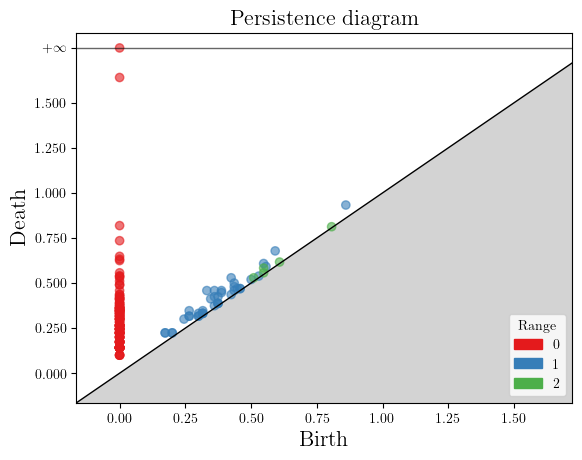

In [5]:
original = vietoris_rips_complex(IRIS.data)
restored = [vietoris_rips_complex(data) for data in restored_data]
persistence_diagram(original["dgms"])

# Normalized Wasserstein Distance

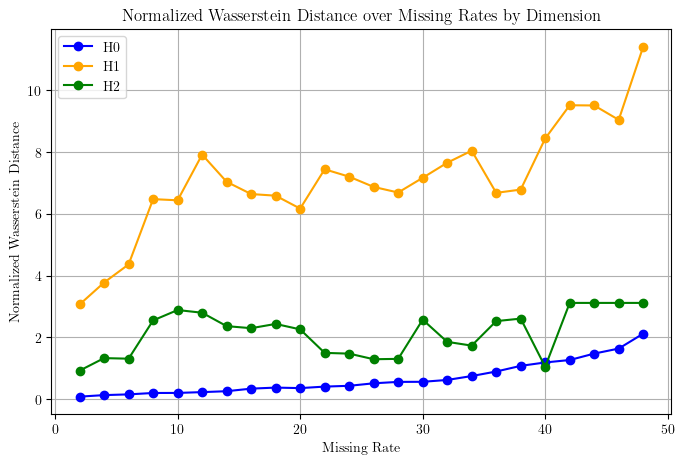

In [6]:
normalized_wasserstein_distances = []

for dim in range(3):
    dim_distances = []
    for i, restored_persistence in enumerate(restored):
        x, y = normalize_by_diameter(
            original["dgms"][dim],
            restored_persistence["dgms"][dim],
            IRIS.data,
            restored_data[i]
        )
        dim_distances.append(compute_normalized_wasserstein_distance(x, y))
    normalized_wasserstein_distances.append(dim_distances)

plot_distance_over_missingrates(normalized_wasserstein_distances, 'Normalized Wasserstein')

# Normalized Bottleneck Distance

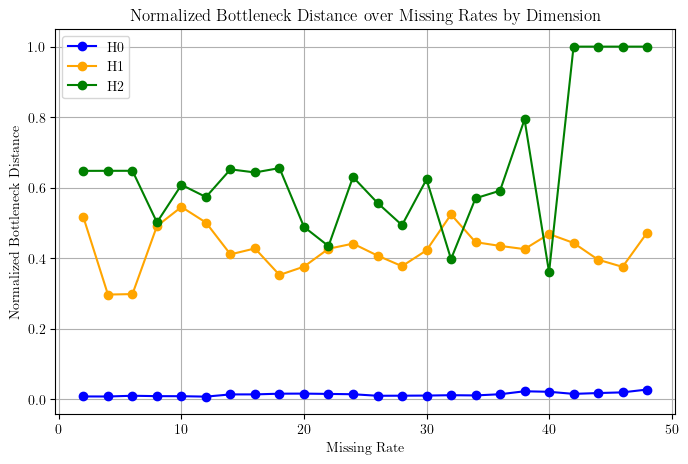

In [7]:
normalized_bottleneck_distances = []

for dim in range(3):
    dim_distances = []
    for i, restored_persistence in enumerate(restored):
        x, y = normalize_by_diameter(
            original["dgms"][dim],
            restored_persistence["dgms"][dim],
            IRIS.data,
            restored_data[i]
        )
        dim_distances.append(compute_normalized_bottleneck_distance(x, y))
    normalized_bottleneck_distances.append(dim_distances)

plot_distance_over_missingrates(normalized_bottleneck_distances, 'Normalized Bottleneck')